# Multi-Pair Results: MNIST and Fashion-MNIST

This notebook runs a fixed-hyperparameter diagnostic benchmark across multiple binary pairs.

Purpose for the meeting:

- compare Raw SVM, Separate Dictionary + SVM, Separate Prototype + SVM, and Joint Prototype + SVM across several pairs;
- separate the effect of the prototype/simplex representation from the effect of joint optimization;
- inspect whether the joint prototype method behaves consistently across task difficulty;
- visualize accuracy, overfitting gap, margin behaviour, reconstruction, and sparsity;
- avoid per-pair hyperparameter tuning for now, so the comparison remains simple and fast to explain.

Important: these are not final tuned results. They are diagnostic results under one fixed configuration.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import math
import numpy as np
import matplotlib.pyplot as plt

from src.config import default_hyperparams, mnist_task_suite, fashion_task_suite
from src.data import load_task
from src.init import initialize_params
from src.solver import fit_joint_pg
from src.metrics import infer_codes_with_dictionary
from src.experiments import (
    run_task_suite,
    flatten_comparison_rows,
    summarize_method_aggregate,
    format_method_aggregate_summary,
)

from src.explainability import (
    margin_diagnostics,
    select_representative_indices,
    sample_explanation,
    format_sample_explanation,
    plot_margin_distribution,
    svm_margin_projection,
    plot_svm_margin_projection,
    plot_sample_explanation,
)


## Fixed Hyperparameters

For this diagnostic benchmark, dictionary-based methods share the same capacity, regularization scale, classifier regularization, and training budget. The separate baseline keeps the original L1 sparse-coding representation, while the joint method enables the prototype-learning variant where each code vector lies on the probability simplex: nonnegative coefficients with column sum equal to one.

The baseline and joint models share representation/classifier controls where possible:

- `dictionary_size`, `mu`, `gamma`, `max_iter`, and solver settings are common;
- `rho`, `eta`, and initialization scales are joint-specific;
- `baseline_hyper.code_simplex = False` keeps the separate baseline as the original L1 sparse dictionary method;
- `joint_hyper.code_simplex = True` makes each joint sample a convex combination of dictionary atoms;
- no validation-based tuning is performed in this notebook.


In [2]:
baseline_hyper = default_hyperparams()
joint_hyper = default_hyperparams()

# Shared controls for dictionary capacity, sparsity scale, classifier regularization, and budget.
for hyper in (baseline_hyper, joint_hyper):
    hyper.dictionary_size = 48
    hyper.mu = 0.5
    hyper.gamma = 10
    hyper.max_iter = 100
    hyper.random_state = 42

# Keep the separate baseline as the original L1 sparse dictionary method.
baseline_hyper.code_simplex = False

# Joint prototype-learning variant: C columns are nonnegative and sum to one.
joint_hyper.code_simplex = True
joint_hyper.rho = 10
joint_hyper.eta = 10
joint_hyper.init_code_scale = 5e-3
joint_hyper.init_classifier_scale = 5e-3

print('baseline_hyper:', baseline_hyper)
print('joint_hyper:', joint_hyper)


baseline_hyper: HyperParams(dictionary_size=48, mu=0.5, code_simplex=False, rho=1.0, gamma=10, w_l1=0.0, eta=1.0, init_code_scale=0.001, init_classifier_scale=0.001, initial_step=1.0, backtracking_shrink=0.5, backtracking_min_step=1e-08, max_iter=100, tol=1e-05, random_state=42, code_correction_every=0, code_correction_max_iter=50, code_correction_blend=1.0, code_correction_update_u=True)
joint_hyper: HyperParams(dictionary_size=48, mu=0.5, code_simplex=True, rho=10, gamma=10, w_l1=0.0, eta=10, init_code_scale=0.005, init_classifier_scale=0.005, initial_step=1.0, backtracking_shrink=0.5, backtracking_min_step=1e-08, max_iter=100, tol=1e-05, random_state=42, code_correction_every=0, code_correction_max_iter=50, code_correction_blend=1.0, code_correction_update_u=True)


## Task Suite

The suite includes four MNIST digit pairs and four Fashion-MNIST pairs.

The goal is not to cherry-pick a single favorable pair, but to observe whether the joint method is stable across easier and harder binary tasks.

In [3]:
tasks = list(mnist_task_suite()) + list(fashion_task_suite())

for task in tasks:
    print(f'{task.dataset:13s} | {task.name:20s} | {task.label_description()}')


mnist         | 3 vs 8               | 3 vs 8
mnist         | 4 vs 9               | 4 vs 9
mnist         | 1 vs 7               | 1 vs 7
mnist         | 5 vs 8               | 5 vs 8
fashion_mnist | T-shirt vs Shirt     | 0 vs 6
fashion_mnist | Pullover vs Coat     | 2 vs 4
fashion_mnist | Dress vs Coat        | 3 vs 4
fashion_mnist | Sandal vs Sneaker    | 5 vs 7


## Run Benchmark

This cell runs all methods on all pairs. It may take a while because each pair trains Raw SVM, Separate Dictionary + SVM, Separate Prototype + SVM, and Joint Prototype + SVM.


In [4]:
task_results = run_task_suite(tasks, baseline_hyper, joint_hyper)
comparison_rows = flatten_comparison_rows(task_results)

task_meta = {result['task']['name']: result['task'] for result in task_results}
for row in comparison_rows:
    meta = task_meta[row['task']]
    row['dataset'] = meta['dataset']
    row['pair'] = meta['name']
    row['train_test_gap'] = row['train_accuracy'] - row['test_accuracy']

print(f'completed tasks: {len(task_results)}')
print(f'comparison rows: {len(comparison_rows)}')


completed tasks: 8
comparison rows: 32


## Table Helpers

In [5]:
def _format_value(value, digits=4):
    if value is None:
        return ''
    if isinstance(value, float):
        if not math.isfinite(value):
            return ''
        return f'{value:.{digits}g}'
    return str(value)


def print_table(rows, columns, digits=4, max_rows=None):
    selected = rows if max_rows is None else rows[:max_rows]
    print(' | '.join(columns))
    print(' | '.join(['---'] * len(columns)))
    for row in selected:
        print(' | '.join(_format_value(row.get(col), digits=digits) for col in columns))


def aggregate_by_dataset_method(rows):
    grouped = {}
    for row in rows:
        key = (row['dataset'], row['method'])
        grouped.setdefault(key, []).append(row)

    output = []
    metrics = [
        'test_accuracy',
        'train_test_gap',
        'test_violation_rate',
        'test_reconstruction_error',
        'test_code_sparsity_1em3',
    ]
    for (dataset, method), members in sorted(grouped.items()):
        summary = {'dataset': dataset, 'method': method, 'tasks': len(members)}
        for metric in metrics:
            values = np.array([member.get(metric, np.nan) for member in members], dtype=np.float64)
            finite = values[np.isfinite(values)]
            summary[f'{metric}_mean'] = float(finite.mean()) if finite.size else float('nan')
            summary[f'{metric}_std'] = float(finite.std()) if finite.size else float('nan')
        output.append(summary)
    return output


def metric_pivot_table(rows, metric, methods, *, best='min'):
    task_keys = []
    for row in rows:
        key = (row['dataset'], row['pair'])
        if key not in task_keys:
            task_keys.append(key)

    output = []
    for dataset, pair in task_keys:
        row_out = {'dataset': dataset, 'pair': pair}
        method_values = {}
        for method in methods:
            match = next(
                (row for row in rows if row['dataset'] == dataset and row['pair'] == pair and row['method'] == method),
                None,
            )
            value = float('nan') if match is None else float(match.get(metric, float('nan')))
            row_out[method] = value
            if math.isfinite(value):
                method_values[method] = value
        if method_values:
            if best == 'min':
                row_out['best_method'] = min(method_values, key=method_values.get)
            elif best == 'max':
                row_out['best_method'] = max(method_values, key=method_values.get)
            else:
                raise ValueError("best must be 'min' or 'max'")
        else:
            row_out['best_method'] = ''
        output.append(row_out)
    return output


## Task-Level Results

In [6]:
task_columns = [
    'dataset',
    'pair',
    'method',
    'train_accuracy',
    'val_accuracy',
    'test_accuracy',
    'train_test_gap',
    'test_violation_rate',
    'test_reconstruction_error',
    'test_code_sparsity_1em3',
]

print_table(comparison_rows, task_columns, digits=4)


dataset | pair | method | train_accuracy | val_accuracy | test_accuracy | train_test_gap | test_violation_rate | test_reconstruction_error | test_code_sparsity_1em3
--- | --- | --- | --- | --- | --- | --- | --- | --- | ---
mnist | 3 vs 8 | Raw SVM | 0.997 | 0.975 | 0.96 | 0.037 | 0.22 |  | 
mnist | 3 vs 8 | Separate Dict + SVM | 0.963 | 0.97 | 0.95 | 0.013 | 0.815 | 73.89 | 0.1496
mnist | 3 vs 8 | Separate Prototype + SVM | 0.962 | 0.94 | 0.955 | 0.007 | 0.995 | 97.26 | 0.8146
mnist | 3 vs 8 | Joint Prototype + SVM | 1 | 0.93 | 0.9225 | 0.0775 | 0.785 | 104.6 | 0.7918
mnist | 4 vs 9 | Raw SVM | 0.993 | 0.955 | 0.9375 | 0.0555 | 0.285 |  | 
mnist | 4 vs 9 | Separate Dict + SVM | 0.955 | 0.955 | 0.94 | 0.015 | 0.8525 | 57.58 | 0.1761
mnist | 4 vs 9 | Separate Prototype + SVM | 0.956 | 0.94 | 0.9275 | 0.0285 | 0.99 | 84.26 | 0.8247
mnist | 4 vs 9 | Joint Prototype + SVM | 1 | 0.92 | 0.925 | 0.075 | 0.9125 | 93.22 | 0.7982
mnist | 1 vs 7 | Raw SVM | 1 | 0.995 | 0.995 | 0.005 | 0.0675 |  | 

## Standalone Margin Violation Table

Lower `test_violation_rate` means more samples satisfy the SVM margin. This table isolates the discriminative margin evidence from the larger result table.


In [7]:
violation_methods = ['Raw SVM', 'Separate Dict + SVM', 'Separate Prototype + SVM', 'Joint Prototype + SVM']
violation_rows = metric_pivot_table(
    comparison_rows,
    'test_violation_rate',
    violation_methods,
    best='min',
)
print_table(violation_rows, ['dataset', 'pair', *violation_methods, 'best_method'], digits=4)


dataset | pair | Raw SVM | Separate Dict + SVM | Separate Prototype + SVM | Joint Prototype + SVM | best_method
--- | --- | --- | --- | --- | --- | ---
mnist | 3 vs 8 | 0.22 | 0.815 | 0.995 | 0.785 | Raw SVM
mnist | 4 vs 9 | 0.285 | 0.8525 | 0.99 | 0.9125 | Raw SVM
mnist | 1 vs 7 | 0.0675 | 0.9025 | 0.995 | 0.6875 | Raw SVM
mnist | 5 vs 8 | 0.2875 | 0.86 | 0.9725 | 0.7975 | Raw SVM
fashion_mnist | T-shirt vs Shirt | 0.6075 | 0.9275 | 0.9875 | 0.735 | Raw SVM
fashion_mnist | Pullover vs Coat | 0.5325 | 0.94 | 0.9975 | 0.84 | Raw SVM
fashion_mnist | Dress vs Coat | 0.155 | 0.8675 | 0.9775 | 0.66 | Raw SVM
fashion_mnist | Sandal vs Sneaker | 0.2975 | 0.915 | 0.985 | 0.72 | Raw SVM


## Standalone Code Sparsity Table

Higher `test_code_sparsity_1em3` means a larger fraction of coefficients are practically zero. Raw SVM is excluded because it has no learned code representation.


In [8]:
sparsity_methods = ['Separate Dict + SVM', 'Separate Prototype + SVM', 'Joint Prototype + SVM']
sparsity_rows = metric_pivot_table(
    comparison_rows,
    'test_code_sparsity_1em3',
    sparsity_methods,
    best='max',
)
print_table(sparsity_rows, ['dataset', 'pair', *sparsity_methods, 'best_method'], digits=4)


dataset | pair | Separate Dict + SVM | Separate Prototype + SVM | Joint Prototype + SVM | best_method
--- | --- | --- | --- | --- | ---
mnist | 3 vs 8 | 0.1496 | 0.8146 | 0.7918 | Separate Prototype + SVM
mnist | 4 vs 9 | 0.1761 | 0.8247 | 0.7982 | Separate Prototype + SVM
mnist | 1 vs 7 | 0.3872 | 0.8629 | 0.8386 | Separate Prototype + SVM
mnist | 5 vs 8 | 0.148 | 0.8197 | 0.7928 | Separate Prototype + SVM
fashion_mnist | T-shirt vs Shirt | 0.1912 | 0.7674 | 0.7992 | Joint Prototype + SVM
fashion_mnist | Pullover vs Coat | 0.2308 | 0.7798 | 0.8128 | Joint Prototype + SVM
fashion_mnist | Dress vs Coat | 0.1988 | 0.7968 | 0.8114 | Joint Prototype + SVM
fashion_mnist | Sandal vs Sneaker | 0.2639 | 0.7716 | 0.7886 | Joint Prototype + SVM


## Aggregate Results by Dataset and Method

In [9]:
aggregate_rows = aggregate_by_dataset_method(comparison_rows)
aggregate_columns = [
    'dataset',
    'method',
    'tasks',
    'test_accuracy_mean',
    'test_accuracy_std',
    'train_test_gap_mean',
    'test_violation_rate_mean',
    'test_reconstruction_error_mean',
    'test_code_sparsity_1em3_mean',
]

print_table(aggregate_rows, aggregate_columns, digits=4)


dataset | method | tasks | test_accuracy_mean | test_accuracy_std | train_test_gap_mean | test_violation_rate_mean | test_reconstruction_error_mean | test_code_sparsity_1em3_mean
--- | --- | --- | --- | --- | --- | --- | --- | ---
fashion_mnist | Joint Prototype + SVM | 4 | 0.8844 | 0.04117 | 0.1121 | 0.7388 | 79.82 | 0.803
fashion_mnist | Raw SVM | 4 | 0.8919 | 0.05925 | 0.08338 | 0.3981 |  | 
fashion_mnist | Separate Dict + SVM | 4 | 0.8906 | 0.04922 | 0.004125 | 0.9125 | 65.09 | 0.2211
fashion_mnist | Separate Prototype + SVM | 4 | 0.9025 | 0.04654 | -0.01225 | 0.9869 | 71.3 | 0.7789
mnist | Joint Prototype + SVM | 4 | 0.9406 | 0.02445 | 0.05937 | 0.7956 | 94.95 | 0.8054
mnist | Raw SVM | 4 | 0.9594 | 0.02211 | 0.03663 | 0.215 |  | 
mnist | Separate Dict + SVM | 4 | 0.955 | 0.01912 | 0.01 | 0.8575 | 64.76 | 0.2152
mnist | Separate Prototype + SVM | 4 | 0.9619 | 0.02387 | 0.009625 | 0.9881 | 86.47 | 0.8305


## Plot Helpers

In [10]:
METHOD_ORDER = ['Raw SVM', 'Separate Dict + SVM', 'Separate Prototype + SVM', 'Joint Prototype + SVM']
COLORS = {
    'Raw SVM': '#4c78a8',
    'Separate Dict + SVM': '#f58518',
    'Separate Prototype + SVM': '#b279a2',
    'Joint Prototype + SVM': '#54a24b',
}


def _task_label(row):
    prefix = 'MNIST' if row['dataset'] == 'mnist' else 'Fashion'
    return f'{prefix}: {row["pair"]}'


def plot_metric_by_task(rows, metric, title, ylabel):
    labels = []
    for row in rows:
        label = _task_label(row)
        if label not in labels:
            labels.append(label)

    x = np.arange(len(labels), dtype=np.float64)
    width = min(0.8 / max(1, len(METHOD_ORDER)), 0.22)
    center = (len(METHOD_ORDER) - 1) / 2.0
    fig, ax = plt.subplots(figsize=(max(10, len(labels) * 1.2), 4.8))

    for idx, method in enumerate(METHOD_ORDER):
        values = []
        for label in labels:
            match = next((row for row in rows if _task_label(row) == label and row['method'] == method), None)
            value = float('nan') if match is None else float(match.get(metric, float('nan')))
            values.append(value)
        ax.bar(x + (idx - center) * width, values, width=width, label=method, color=COLORS[method])

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=35, ha='right')
    ax.grid(axis='y', alpha=0.25)
    ax.legend()
    fig.tight_layout()
    return fig, ax


def plot_tradeoff(rows, x_metric, y_metric, title, xlabel, ylabel):
    fig, ax = plt.subplots(figsize=(7, 5))
    for method in METHOD_ORDER:
        method_rows = [row for row in rows if row['method'] == method]
        xs = np.array([row.get(x_metric, np.nan) for row in method_rows], dtype=np.float64)
        ys = np.array([row.get(y_metric, np.nan) for row in method_rows], dtype=np.float64)
        mask = np.isfinite(xs) & np.isfinite(ys)
        if np.any(mask):
            ax.scatter(xs[mask], ys[mask], label=method, color=COLORS[method], s=55, alpha=0.85)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.25)
    ax.legend()
    fig.tight_layout()
    return fig, ax


## Main Result Visualizations

The main plots focus on the agreed evidence: accuracy, train-test generalization gap, margin violation, reconstruction-vs-accuracy, and sparsity-vs-accuracy.


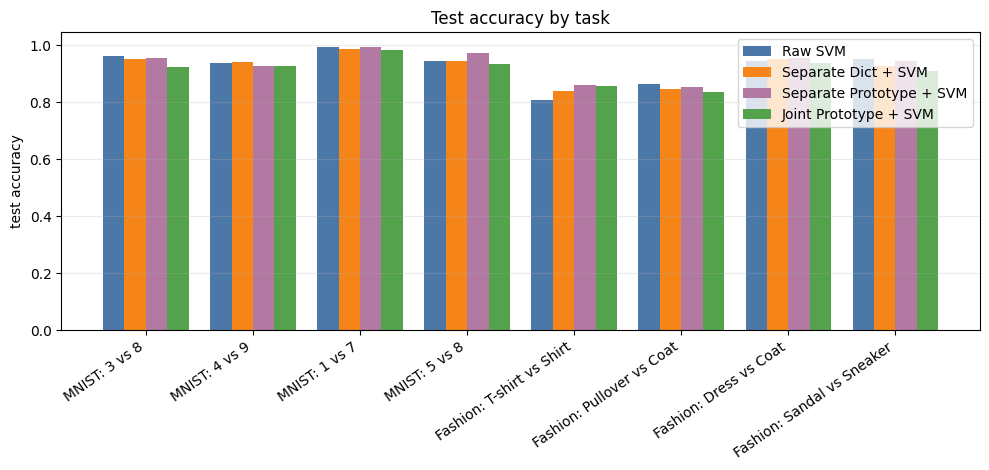

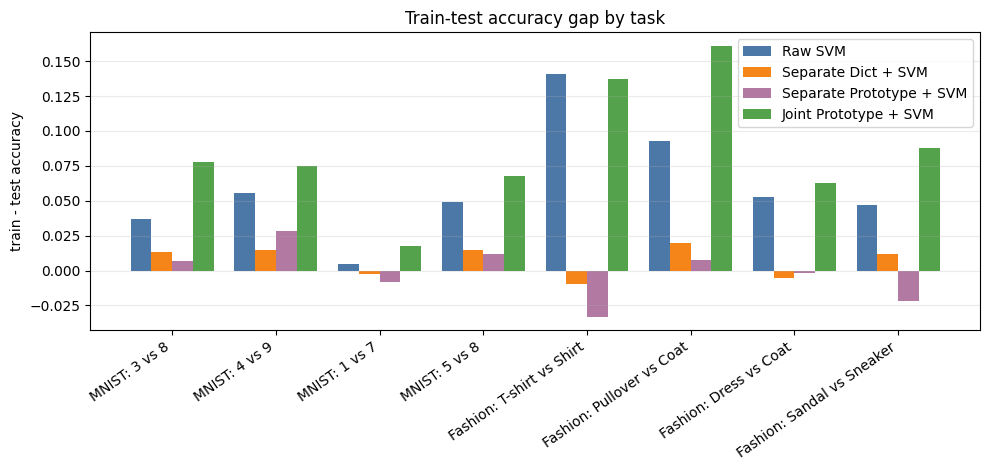

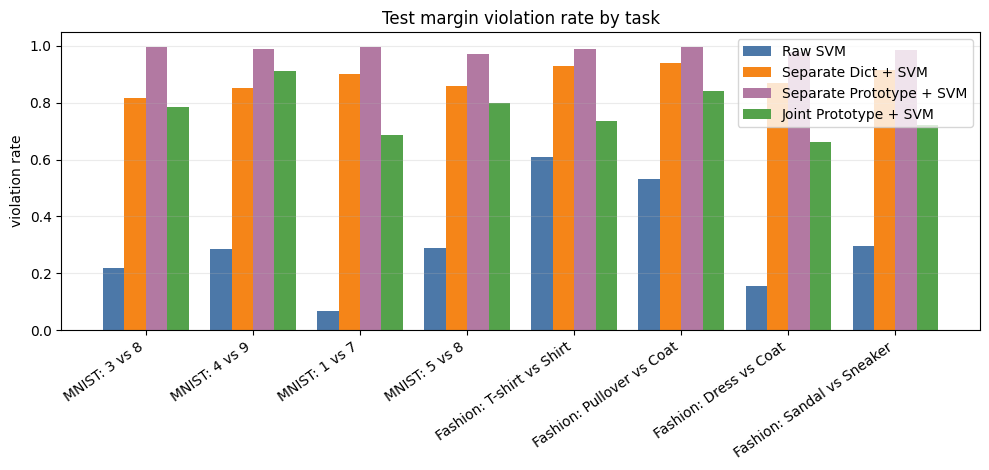

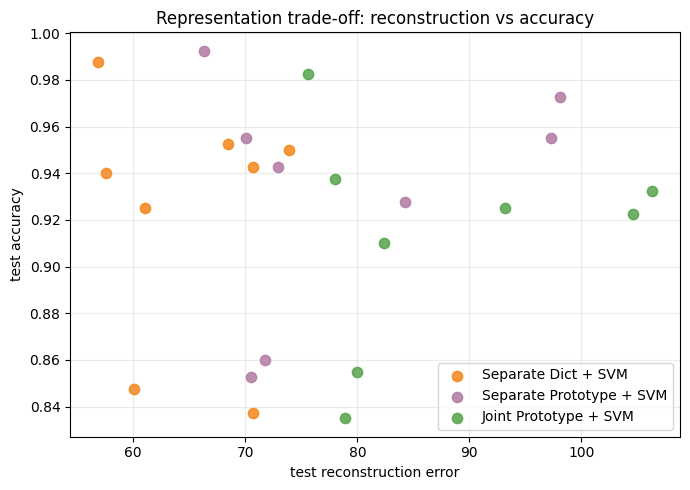

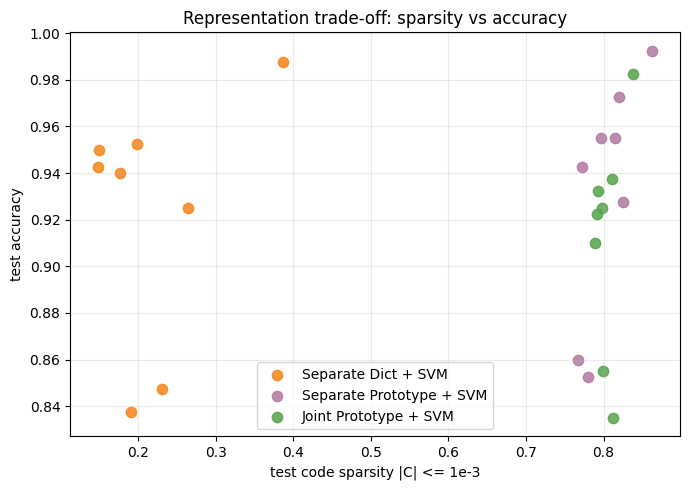

In [11]:
plot_metric_by_task(comparison_rows, 'test_accuracy', 'Test accuracy by task', 'test accuracy')
plot_metric_by_task(comparison_rows, 'train_test_gap', 'Train-test accuracy gap by task', 'train - test accuracy')
plot_metric_by_task(comparison_rows, 'test_violation_rate', 'Test margin violation rate by task', 'violation rate')
plot_tradeoff(
    comparison_rows,
    'test_reconstruction_error',
    'test_accuracy',
    'Representation trade-off: reconstruction vs accuracy',
    'test reconstruction error',
    'test accuracy',
)
plot_tradeoff(
    comparison_rows,
    'test_code_sparsity_1em3',
    'test_accuracy',
    'Representation trade-off: sparsity vs accuracy',
    'test code sparsity |C| <= 1e-3',
    'test accuracy',
)
plt.show()


## Explainability: SVM Margins and Atom Contributions

This section gives a standard SVM-style visualization for two representative tasks:

- Fashion-MNIST `T-shirt vs Shirt`, because it is a harder visual task;
- MNIST `3 vs 8`, because the digits are easy to interpret visually.

For each selected task, each method is projected into a two-dimensional SVM margin view:

- x-axis: signed geometric distance to the decision boundary;
- vertical black line: decision boundary;
- vertical red dashed lines: the two SVM unit-margin lines;
- y-axis: the leading variation orthogonal to the classifier direction.

This makes margin violation visually clear. Points between the two red margin lines are inside the margin, and points on the wrong side of the black boundary are misclassified.

The section also shows atom-level explanations for the joint prototype model: original image, reconstruction, residual, top active prototypes, and classifier contribution `w_i c_i`.


In [12]:
def build_explainability_context(explain_task):
    X_train_e, y_train_e, X_val_e, y_val_e, X_test_e, y_test_e = load_task(explain_task)
    result_e = next(
        result for result in task_results
        if result['task']['dataset'] == explain_task.dataset and result['task']['name'] == explain_task.name
    )

    raw_model_e = result_e['raw']['model']
    raw_w_e = raw_model_e.coef_.reshape(-1)
    raw_b_e = float(raw_model_e.intercept_[0])

    separate_result_e = result_e['separate']
    separate_model_e = separate_result_e['model']
    separate_C_test_e = separate_result_e['codes_test']
    separate_w_e = separate_model_e.coef_.reshape(-1)
    separate_b_e = float(separate_model_e.intercept_[0])

    separate_prototype_result_e = result_e.get('separate_prototype')

    joint_result_e = result_e['joint']['result']
    joint_params_e = joint_result_e['params']
    joint_C_test_e = infer_codes_with_dictionary(
        X=X_test_e,
        D=joint_params_e['D'],
        mu=joint_hyper.mu,
        initial_step=joint_hyper.initial_step,
        backtracking_shrink=joint_hyper.backtracking_shrink,
        backtracking_min_step=joint_hyper.backtracking_min_step,
        max_iter=joint_hyper.max_iter,
        tol=joint_hyper.tol,
        simplex=getattr(joint_hyper, 'code_simplex', False),
    )

    margin_views = {
        'Raw SVM': svm_margin_projection(X_test_e, y_test_e, raw_w_e, raw_b_e),
        'Separate Dict + SVM': svm_margin_projection(separate_C_test_e, y_test_e, separate_w_e, separate_b_e),
    }
    if separate_prototype_result_e is not None:
        proto_model_e = separate_prototype_result_e['model']
        margin_views['Separate Prototype + SVM'] = svm_margin_projection(
            separate_prototype_result_e['codes_test'],
            y_test_e,
            proto_model_e.coef_.reshape(-1),
            float(proto_model_e.intercept_[0]),
        )
    margin_views['Joint Prototype + SVM'] = svm_margin_projection(
        joint_C_test_e, y_test_e, joint_params_e['w'], float(joint_params_e['b'])
    )

    return {
        'task': explain_task,
        'X_test': X_test_e,
        'y_test': y_test_e,
        'joint_params': joint_params_e,
        'joint_C_test': joint_C_test_e,
        'margin_views': margin_views,
    }


explain_tasks = [
    next(task for task in tasks if task.dataset == 'fashion_mnist' and task.name == 'T-shirt vs Shirt'),
    next(task for task in tasks if task.dataset == 'mnist' and task.name == '3 vs 8'),
]
explainability_contexts = [build_explainability_context(task) for task in explain_tasks]

for context in explainability_contexts:
    task = context['task']
    print('task:', task.dataset, task.name)
    for method, projection in context['margin_views'].items():
        acc = float(np.mean(projection['predictions'] == context['y_test']))
        violation = float(np.mean(context['y_test'] * projection['scores'] < 1.0))
        print(f"{method}: accuracy={acc:.4f}, violation_rate={violation:.4f}")
    print()


task: fashion_mnist T-shirt vs Shirt
Raw SVM: accuracy=0.8075, violation_rate=0.6075
Separate Dict + SVM: accuracy=0.8375, violation_rate=0.9275
Separate Prototype + SVM: accuracy=0.8600, violation_rate=0.9875
Joint Prototype + SVM: accuracy=0.8550, violation_rate=0.7350

task: mnist 3 vs 8
Raw SVM: accuracy=0.9600, violation_rate=0.2200
Separate Dict + SVM: accuracy=0.9500, violation_rate=0.8150
Separate Prototype + SVM: accuracy=0.9550, violation_rate=0.9950
Joint Prototype + SVM: accuracy=0.9225, violation_rate=0.7850



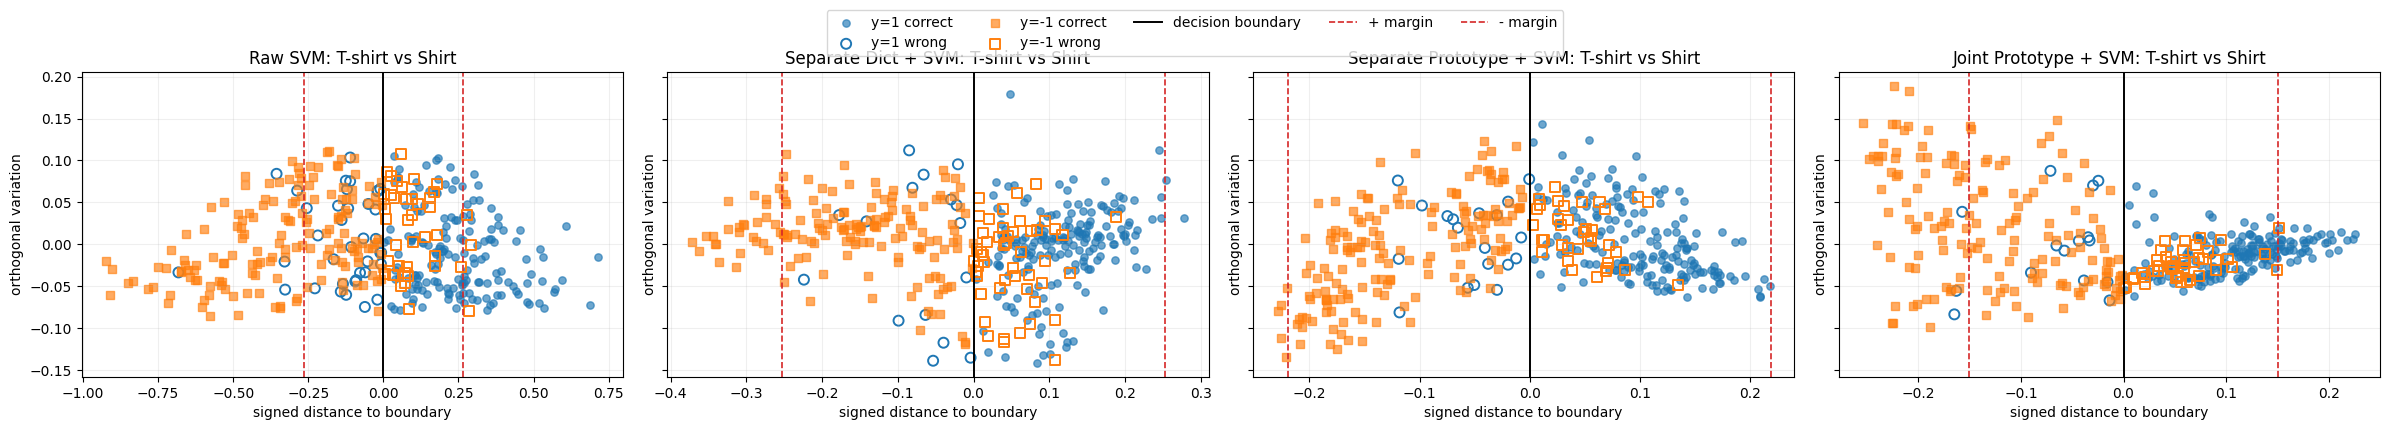

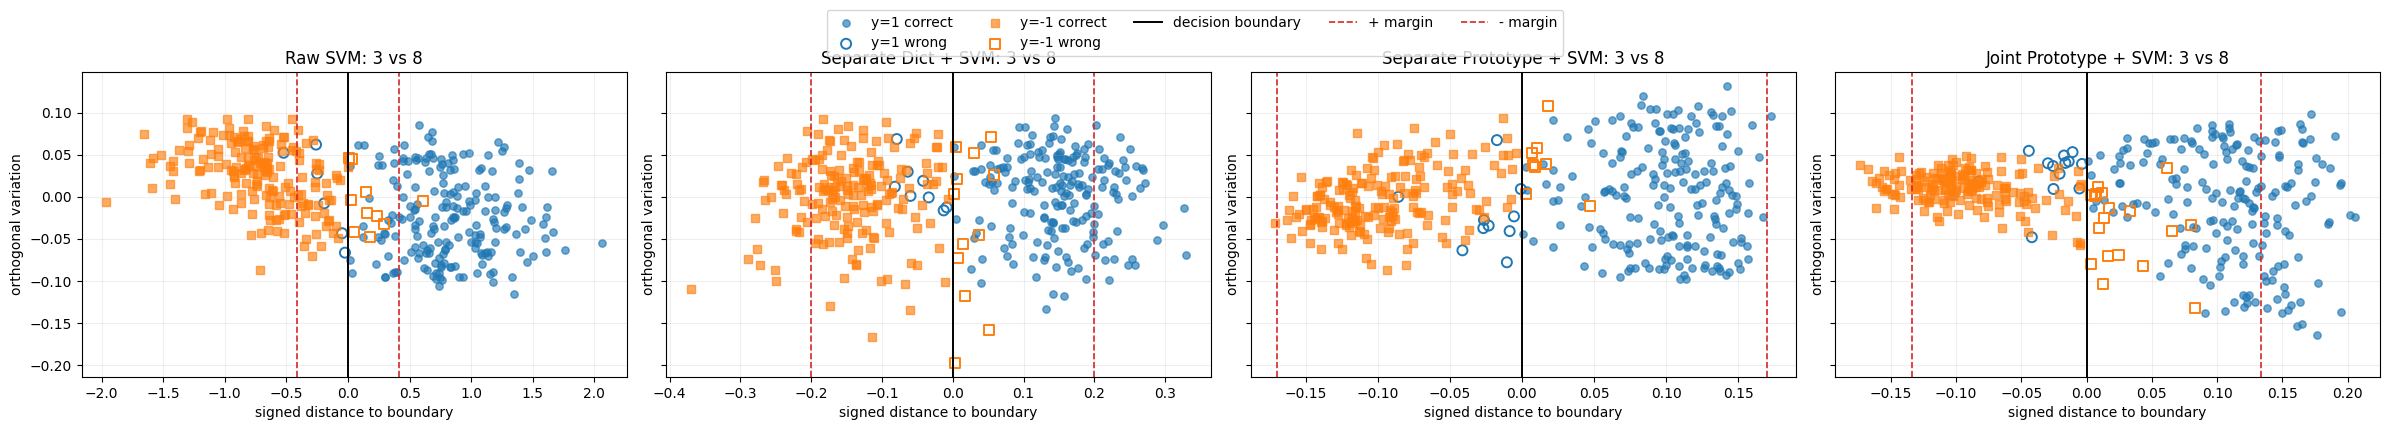

In [13]:
for context in explainability_contexts:
    task = context['task']
    margin_views = context['margin_views']
    fig, axes = plt.subplots(1, len(margin_views), figsize=(6 * len(margin_views), 4), sharey=True)
    axes = np.atleast_1d(axes)
    for ax, (method, projection) in zip(axes, margin_views.items()):
        plot_svm_margin_projection(projection, ax=ax, title=f'{method}: {task.name}')
    handles, labels = axes[-1].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=5, bbox_to_anchor=(0.5, 1.08))
    fig.tight_layout()
    plt.show()


joint selected examples for fashion_mnist T-shirt vs Shirt: {'strong_correct': [39], 'violated_correct': [28], 'misclassified': [80]}

=== fashion_mnist T-shirt vs Shirt | strong_correct: sample 39 ===
field | value
index | 39
label | -1
prediction | -1
correct | True
score | -1.68301
signed_margin | 1.68301
margin_residual | -0.683009
positive_violation | 0
violated | False

atom | coeff | classifier_weight | score_contribution
6 | 0.644747 | -2.05425 | -1.32447
31 | 0.273909 | -1.99583 | -0.546676
12 | 0.0637935 | -0.294648 | -0.0187967
30 | 0.0147719 | -1.01956 | -0.0150609
24 | 0.00277837 | -0.690699 | -0.00191902
47 | 0 | 0.172924 | 0


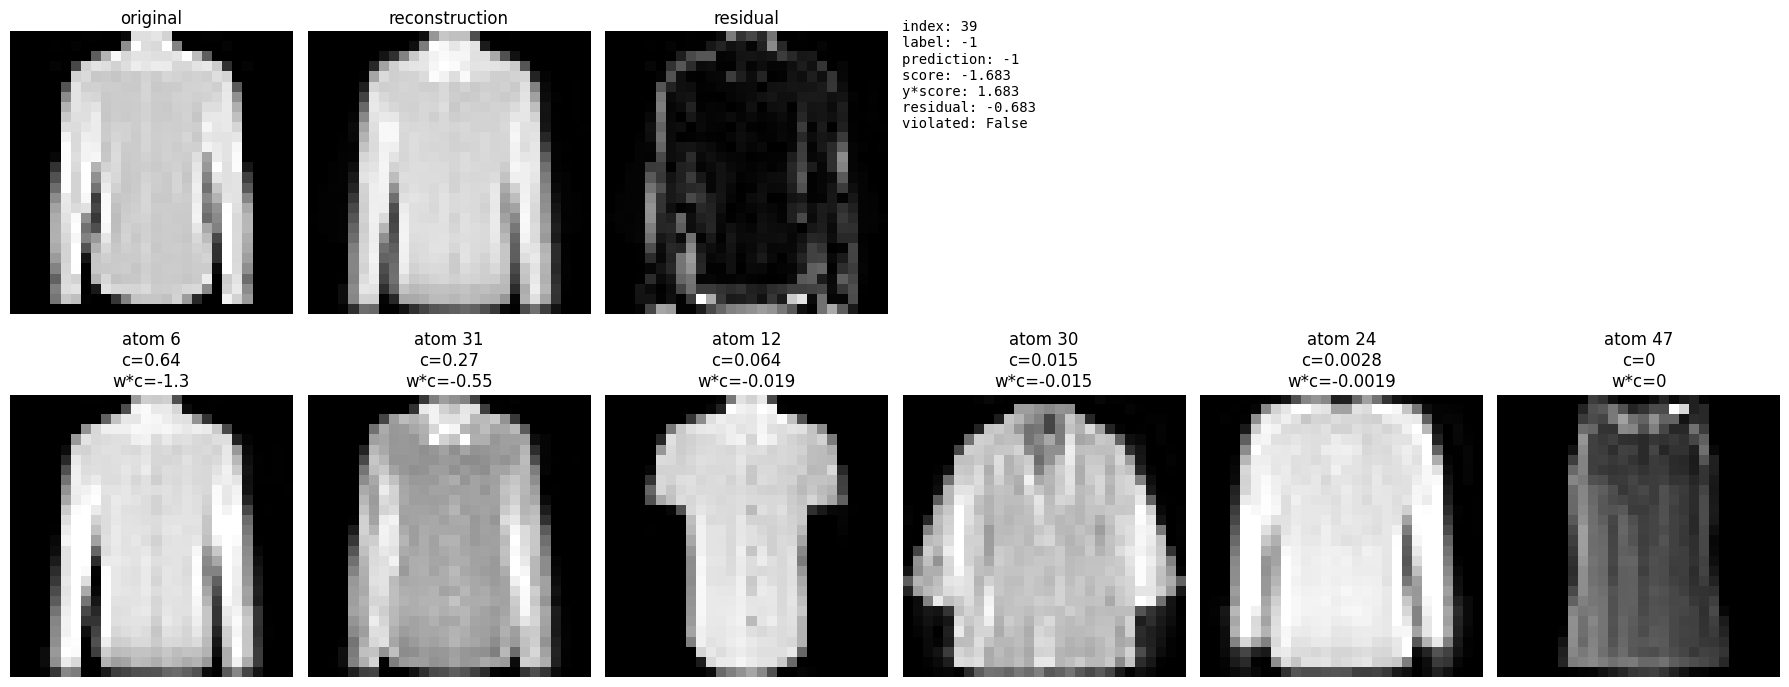


=== fashion_mnist T-shirt vs Shirt | violated_correct: sample 28 ===
field | value
index | 28
label | 1
prediction | 1
correct | True
score | 0.00997412
signed_margin | 0.00997412
margin_residual | 0.990026
positive_violation | 0.990026
violated | True

atom | coeff | classifier_weight | score_contribution
3 | 0.227234 | -0.43804 | -0.0995374
39 | 0.216493 | 0.15953 | 0.0345371
47 | 0.14454 | 0.172924 | 0.0249944
14 | 0.109464 | 0.846523 | 0.0926637
43 | 0.105054 | 0.653064 | 0.068607
25 | 0.0858962 | -1.48319 | -0.1274


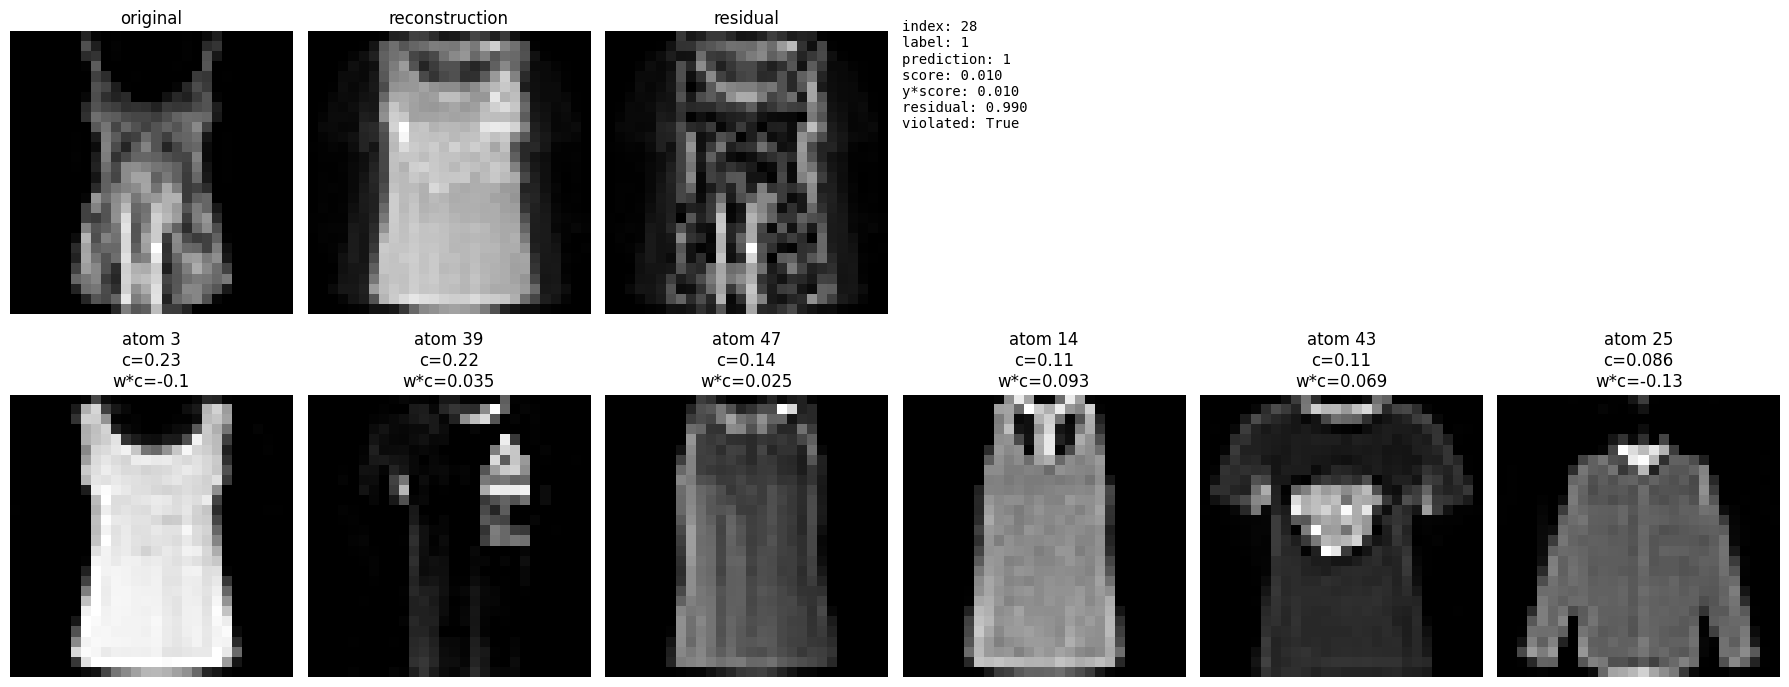


=== fashion_mnist T-shirt vs Shirt | misclassified: sample 80 ===
field | value
index | 80
label | 1
prediction | -1
correct | False
score | -1.09449
signed_margin | -1.09449
margin_residual | 2.09449
positive_violation | 2.09449
violated | True

atom | coeff | classifier_weight | score_contribution
4 | 0.48317 | -2.04647 | -0.988794
20 | 0.15358 | -0.982517 | -0.150894
39 | 0.115402 | 0.15953 | 0.01841
22 | 0.0999637 | -1.0485 | -0.104812
25 | 0.0782917 | -1.48319 | -0.116121
27 | 0.0695931 | 0.342122 | 0.0238093


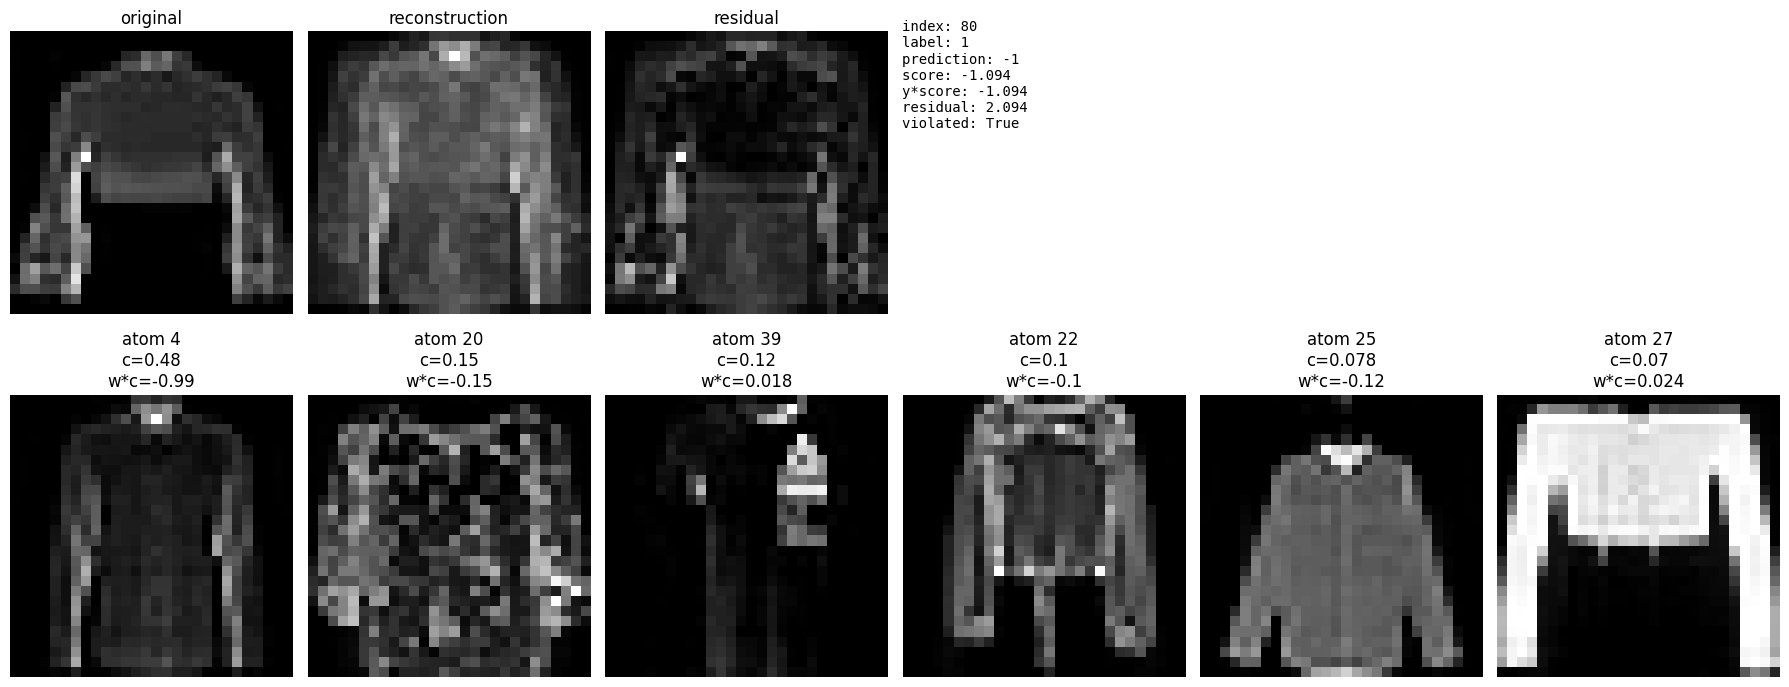

joint selected examples for mnist 3 vs 8: {'strong_correct': [90], 'violated_correct': [197], 'misclassified': [231]}

=== mnist 3 vs 8 | strong_correct: sample 90 ===
field | value
index | 90
label | 1
prediction | 1
correct | True
score | 1.54106
signed_margin | 1.54106
margin_residual | -0.541059
positive_violation | 0
violated | False

atom | coeff | classifier_weight | score_contribution
39 | 0.413447 | 1.4634 | 0.605038
18 | 0.350215 | 1.67319 | 0.585977
35 | 0.0860543 | 1.89089 | 0.162719
46 | 0.063047 | 1.1643 | 0.0734058
8 | 0.0525279 | 1.39166 | 0.0731011
28 | 0.0347087 | 0.454422 | 0.0157724


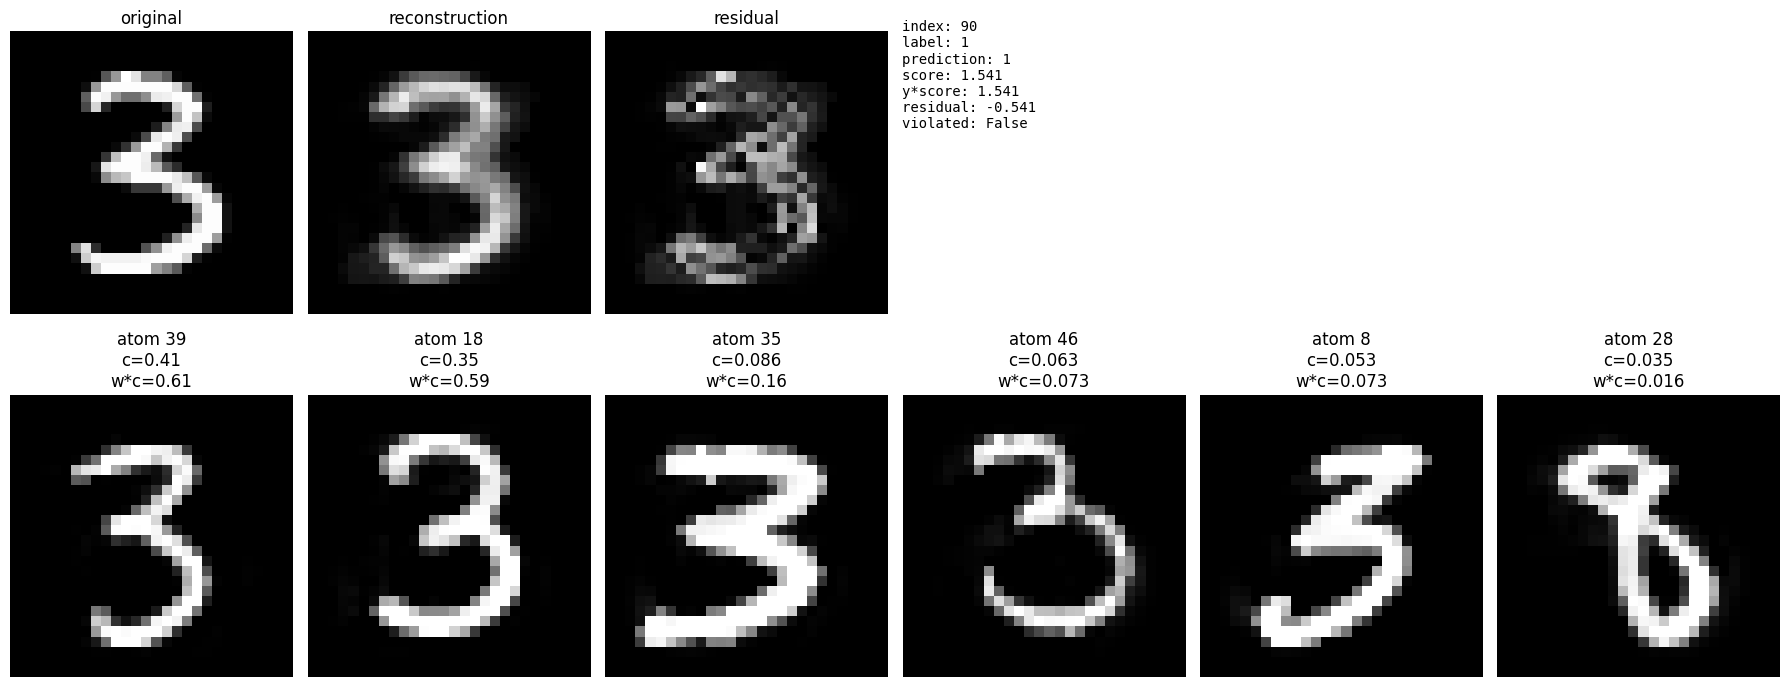


=== mnist 3 vs 8 | violated_correct: sample 197 ===
field | value
index | 197
label | 1
prediction | 1
correct | True
score | 0.00522352
signed_margin | 0.00522352
margin_residual | 0.994776
positive_violation | 0.994776
violated | True

atom | coeff | classifier_weight | score_contribution
40 | 0.269243 | 0.128534 | 0.034607
9 | 0.178871 | 0.918068 | 0.164215
2 | 0.11358 | -0.556541 | -0.0632117
29 | 0.105191 | -1.0624 | -0.111754
31 | 0.100917 | 0.770343 | 0.0777407
13 | 0.0911708 | -1.36716 | -0.124645


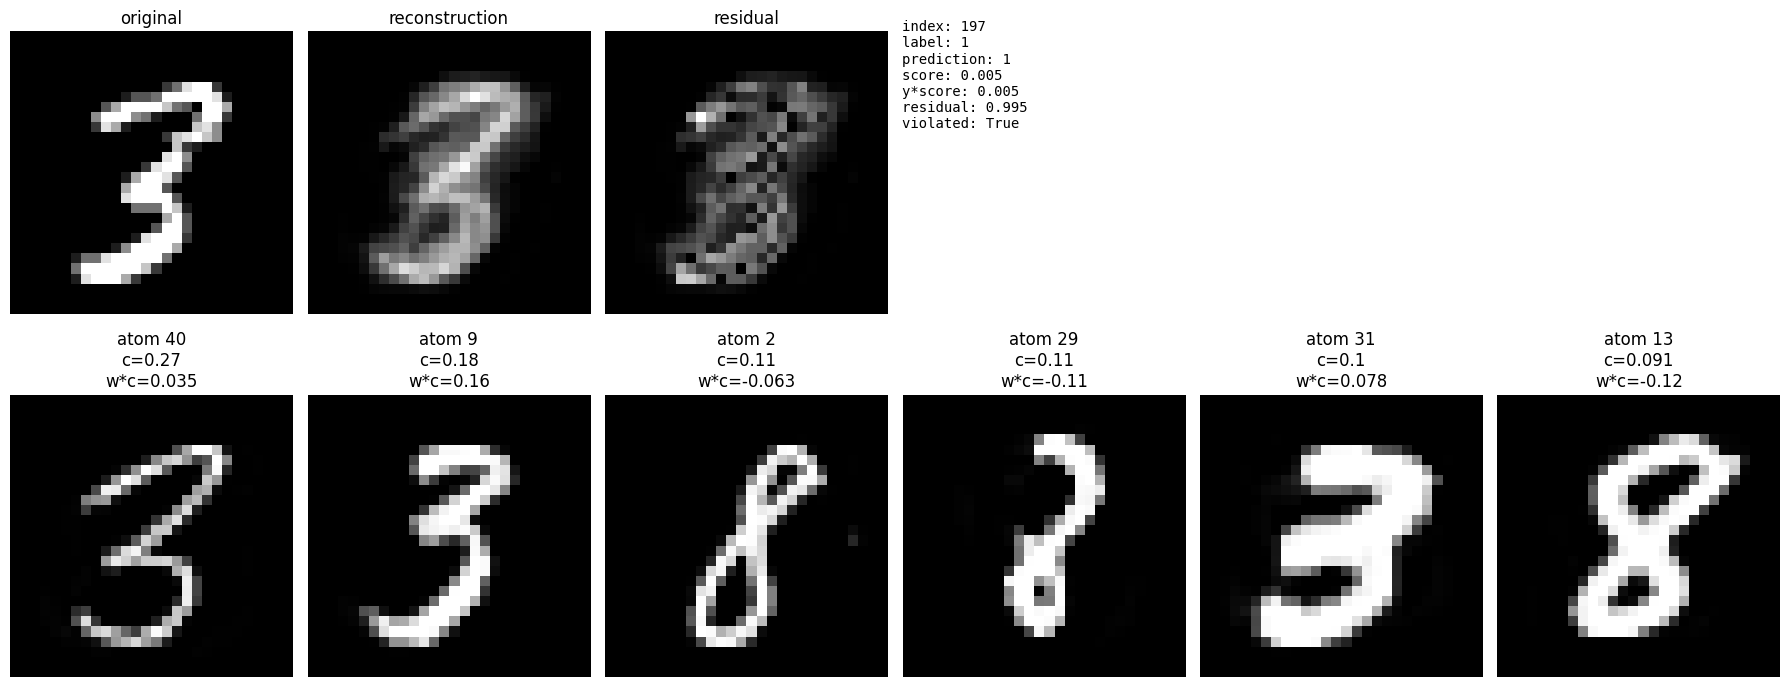


=== mnist 3 vs 8 | misclassified: sample 231 ===
field | value
index | 231
label | -1
prediction | 1
correct | False
score | 0.621076
signed_margin | -0.621076
margin_residual | 1.62108
positive_violation | 1.62108
violated | True

atom | coeff | classifier_weight | score_contribution
0 | 0.371443 | 1.38775 | 0.515471
30 | 0.254194 | 1.22222 | 0.310681
20 | 0.160956 | -1.2271 | -0.197509
31 | 0.0780621 | 0.770343 | 0.0601346
38 | 0.0665442 | -1.57338 | -0.104699
24 | 0.0569528 | 0.470537 | 0.0267984


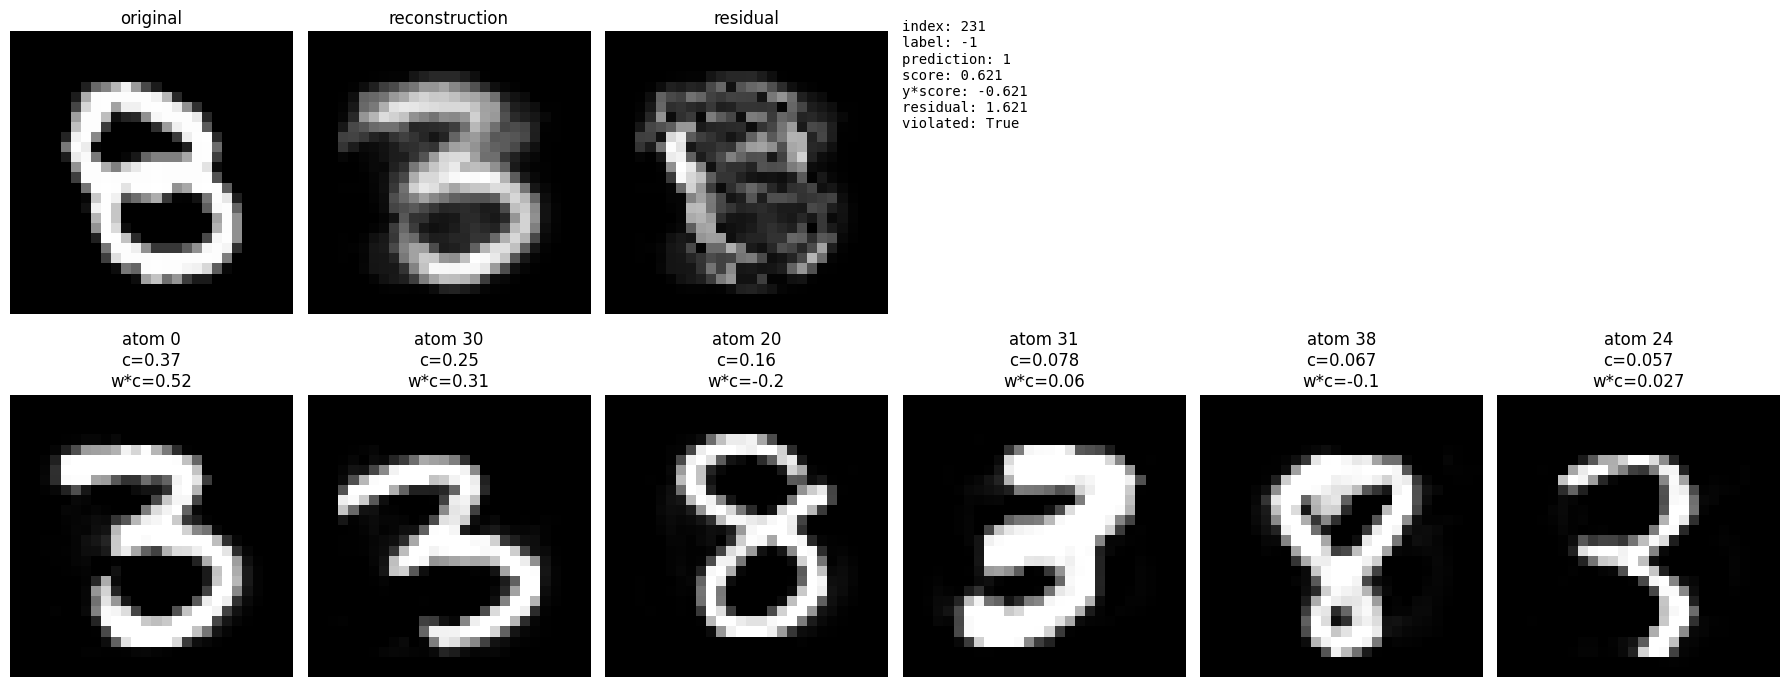

In [14]:
for context in explainability_contexts:
    task = context['task']
    X_test_e = context['X_test']
    y_test_e = context['y_test']
    joint_params_e = context['joint_params']
    joint_C_test_e = context['joint_C_test']

    joint_diag_e = margin_diagnostics(joint_C_test_e, y_test_e, joint_params_e['w'], float(joint_params_e['b']))
    selected_examples = select_representative_indices(joint_diag_e, max_per_group=1)
    print(f'joint selected examples for {task.dataset} {task.name}:', {key: value.tolist() for key, value in selected_examples.items()})

    for group_name, indices in selected_examples.items():
        for sample_idx in indices:
            explanation = sample_explanation(
                X_test_e,
                joint_params_e['D'],
                joint_C_test_e,
                y_test_e,
                joint_params_e['w'],
                float(joint_params_e['b']),
                int(sample_idx),
                top_k=6,
            )
            print(f'\n=== {task.dataset} {task.name} | {group_name}: sample {int(sample_idx)} ===')
            print(format_sample_explanation(explanation))
            plot_sample_explanation(explanation, joint_params_e['D'], top_k=6)
            plt.show()


## Meeting Notes Template

Use the cells above to fill in these points before the meeting:

- Does joint improve, match, or underperform separate dictionary learning on MNIST pairs?
- Does the behavior change on Fashion-MNIST pairs?
- Is the joint method mainly suffering from lower accuracy, larger train-test gap, or larger margin violation?
- Does joint provide a better reconstruction/sparsity trade-off even when accuracy is not higher?
- Should the next stage be systematic validation tuning, task selection, or objective modification?